## Import библиотек и модулей


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import json

from pathlib import Path
import re
from datetime import datetime, timedelta
# --- Настройка путей и sys.path ---
# Добавляем корневую директорию проекта в sys.path для импорта кастомных модулей
PROJECT_ROOT = Path().cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.config import path_config, database
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from concurrent.futures import ThreadPoolExecutor, as_completed
from sqlalchemy import text
import os, sys
import re
from datetime import datetime, timedelta
# --- Настройка путей и sys.path ---
# Добавляем корневую директорию проекта в sys.path для импорта кастомных модулей
PROJECT_ROOT = Path().cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.logger import logger
from src.database import clickhouse_engine

2026-03-19 09:41:34,053 | my_logger - INFO - ✅ ClickHouse engine создан | /data/aturov/universal_control_group/src/database.py:21


In [2]:
DATA_START = "2026-02-01" # --- Дата начала периода для анализа (включительно) ---

df_final = pd.read_parquet(path_config.data_processed_path / f"ukg_eligible_final_{DATA_START}.parquet")

# EDA месячного среза DM Datamart Monthly

Этот ноутбук оформлен по best practices для feature-level EDA на одном месячном срезе.

Структура:
1. Общий профиль данных и первичная диагностика
2. Словарь признаков с русскими описаниями
3. Обоснование выбора колонок для UKG split
4. Графики по выбранным колонкам
5. Полный feature passport по всем фичам
6. Риски данных: пропуски, выбросы, скошенность, `1970-01-01` как sentinel для дат
7. Выводы и рекомендации для будущей модели

Важно:
- это EDA для одного месячного среза, без анализа стабильности во времени
- логика split и проверки баланса вынесены в отдельный ноутбук

In [3]:
import warnings
import seaborn as sns

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

TOP_MISSING_FEATURES = 15
MAX_CATEGORY_UNIQUE_VALUES = 200
ID_CANDIDATES = ["SUBS_ID", "subscriber_id", "subs_id", "SUBSCRIBER_ID", "CTN"]

CLICKHOUSE_DATE_FORMAT = {
    "DT": "days",
    "DATE_INACTIVE": "days",
    "DATE_LAD": "days",
    "PRICE_CHANGE_DATE": "seconds",
    "ACT_DATE": "seconds",
    "DATE_ABONKA": "seconds",
    "DATE_CONTRACT": "seconds",
}



def detect_id_column(df: pd.DataFrame, candidates: list[str] | None = None) -> str:
    candidates = candidates or ID_CANDIDATES
    for column in candidates:
        if column in df.columns:
            return column
    raise ValueError(f"Не найден идентификатор абонента. Проверенные варианты: {candidates}")



def cast_clickhouse_date_columns(df: pd.DataFrame, date_format_map: dict[str, str] | None = None) -> pd.DataFrame:
    mapped = date_format_map or CLICKHOUSE_DATE_FORMAT
    result = df.copy()

    for column, fmt in mapped.items():
        if column not in result.columns:
            continue

        raw = pd.to_numeric(result[column], errors="coerce")
        if fmt == "days":
            result[column] = pd.to_datetime(raw, unit="D", origin="1970-01-01", errors="coerce")
        elif fmt == "seconds":
            result[column] = pd.to_datetime(raw, unit="s", origin="1970-01-01", errors="coerce")

    return result



def infer_feature_buckets(df: pd.DataFrame, id_col: str, date_format_map: dict[str, str] | None = None) -> tuple[list[str], list[str], list[str]]:
    date_map = date_format_map or CLICKHOUSE_DATE_FORMAT
    date_like_cols = [column for column in date_map if column in df.columns and column != id_col]

    numeric_cols = [
        column
        for column in df.columns
        if column != id_col
        and column not in date_like_cols
        and pd.api.types.is_numeric_dtype(df[column])
    ]
    categorical_cols = [
        column
        for column in df.columns
        if column != id_col
        and column not in date_like_cols
        and column not in numeric_cols
    ]
    return numeric_cols, categorical_cols, date_like_cols



def select_categorical_features_for_profile(
    df: pd.DataFrame,
    categorical_cols: list[str],
    max_unique_values: int = MAX_CATEGORY_UNIQUE_VALUES,
) -> tuple[list[str], pd.DataFrame]:
    stats_rows = []
    selected = []

    for column in categorical_cols:
        unique_values = int(df[column].nunique(dropna=True))
        stats_rows.append(
            {
                "feature": column,
                "unique_values": unique_values,
                "selected_for_profile": unique_values <= max_unique_values,
            }
        )
        if unique_values <= max_unique_values:
            selected.append(column)

    stats_df = pd.DataFrame(stats_rows).sort_values("unique_values", ascending=False).reset_index(drop=True)
    excluded_df = stats_df.loc[~stats_df["selected_for_profile"]].copy()
    return selected, excluded_df

In [4]:
EXCEL_FEATURE_COMMENTS = {
    "DT": "Дата начала расчетного периода.",
    "CTN": "CTN (номер) абонента.",
    "SUBS_ID": "Ключ абонента.",
    "CUST_LEVEL": "Тип клиента: B2B, B2C, Employee и др.",
    "STATUS": "Статус абонента: активный, блокированный, приостановленный и т.д.",
    "REGION_CELL": "Регион по последней базовой станции.",
    "PRICE_PLAN": "Тарифный план абонента на конец расчетного периода.",
    "PRICE_PLAN_RU": "Тарифный план на кириллице.",
    "PERIODICITY": "Периодичность тарифного плана: weekly/monthly и т.д.",
    "SUBSCRIPTION_FEE": "Стоимость абонентской платы действующего тарифа.",
    "PREV_PRICE_PLAN": "Предыдущий тарифный план абонента.",
    "PRICE_CHANGE_DATE": "Дата последней смены тарифного плана.",
    "ORIG_PRICE_PLAN": "Тарифный план на момент активации.",
    "ACT_DATE": "Дата активации абонента.",
    "DATE_INACTIVE": "Дата перехода в неактивный статус.",
    "BALANCE_END": "Баланс абонента на конец периода, сом.",
    "REVENUE_ABONKA": "Сумма списаний за абонентскую плату.",
    "DATE_ABONKA": "Дата последнего списания абонентской платы.",
    "USAGE_ABONKA_TP": "Количество списанных абонентских плат.",
    "TRANZ_FLAG": "Флаг наличия платного события в расчетном периоде.",
    "DAYS_WITHOUT_PAYMENT": "Количество дней без исходящих платных транзакций.",
    "TOTAL_RECHARGE": "Общая сумма пополнений за расчетный период.",
    "COUNT_RECHARGE": "Количество пополнений за расчетный период.",
    "DATE_CONTRACT": "Дата персонификации абонента.",
    "FLAG_4G": "Флаг наличия SIM-карты с поддержкой 4G.",
    "USAGE_NUM_OUT": "Количество исходящих звонков за период.",
    "USAGE_OUT_ONNET_VOICE": "Исходящий внутрисетевой voice-трафик, минуты.",
    "USAGE_OUT_OFFNET_VOICE": "Исходящий трафик на сети конкурентов, минуты.",
    "USAGE_OUT_CITY_VOICE": "Исходящий трафик на городские номера, минуты.",
    "USAGE_OUT_INT_VOICE": "Исходящий международный трафик, минуты.",
    "USAGE_OUT_INT_VOICE_RUSSIA": "Исходящий трафик на номера РФ.",
    "USAGE_IN_ONNET_VOICE": "Входящий внутрисетевой трафик, минуты.",
    "USAGE_IN_OFFNET_VOICE": "Входящий трафик с сетей конкурентов, минуты.",
    "USAGE_VALUELESS_INTERNET": "Суммарный объем бесплатного интернет-трафика, МБ.",
    "USAGE_INTERNET": "Суммарный интернет-трафик, МБ.",
    "USAGE_INTERNET_2G": "Суммарный 2G трафик, МБ.",
    "USAGE_INTERNET_3G": "Суммарный 3G трафик, МБ.",
    "USAGE_INTERNET_LTE": "Суммарный LTE трафик, МБ.",
    "USAGE_INTERNET_3G_FREE": "Бесплатный 3G трафик, МБ.",
    "USAGE_INTERNET_LTE_FREE": "Бесплатный LTE трафик, МБ.",
    "USAGE_OUT_OFFNET_O_VOICE": "Исходящий трафик на номера O!, минуты.",
    "USAGE_OUT_OFFNET_MEGACOM_VOICE": "Исходящий трафик на номера MegaCom, минуты.",
    "USAGE_IN_OFFNET_O_VOICE": "Входящий трафик с номеров O!.",
    "USAGE_IN_OFFNET_MEGACOM_VOICE": "Входящий трафик с номеров MegaCom.",
    "COUNT_SMS": "Количество SMS за период.",
    "REVENUE_VOICE": "Списания за voice-услуги.",
    "REVENUE_VOICE_TO_SERVICE": "Списания за звонки на сервисные номера.",
    "REVENUE_OUT_ONNET_VOICE": "Списания за исходящие внутрисетевые звонки.",
    "REVENUE_OUT_OFFNET_VOICE": "Списания за звонки на других операторов КР.",
    "REVENUE_OUT_CITY_VOICE": "Списания за звонки на фиксированные сети КР.",
    "REVENUE_OUT_INT_VOICE": "Списания за международные звонки.",
    "REVENUE_INTERNET_PAYG": "Начисления за PAYG data traffic.",
    "USAGE_INTERNET_NIGHT": "Ночной интернет-трафик.",
    "USAGE_NUM_INTERNET_PAK": "Количество приобретенных интернет-пакетов.",
    "USAGE_NUM_OFFNET_PAK": "Количество пакетов минут на других операторов.",
    "REVENUE_INTERNET_PAK": "Списания за интернет-пакеты.",
    "REVENUE_OFFNET_PAK": "Списания за пакеты минут вне сети.",
    "INTERCONNECT_MN_IN": "Доход по входящему международному интерконнекту.",
    "INTERCONNECT_MN_OUT": "Расходы по исходящему международному интерконнекту.",
    "INTERCONNECT_LOC_IN": "Доход по входящему локальному интерконнекту.",
    "INTERCONNECT_LOC_OUT": "Расходы по исходящему локальному интерконнекту.",
    "REVENUE_TOTAL_INTERCONNECT": "Совокупная выручка с учетом интерконнекта.",
    "GM": "Gross margin по абоненту.",
    "IVR_LANG": "Язык IVR / услуги 'Свой язык'.",
    "TAC": "Первые 8 символов IMEI телефона.",
    "CELL_ID": "Станция последнего сетевого события.",
    "DEV_NAME": "Название устройства по последнему сетевому событию.",
    "DEV_TYPE": "Тип устройства.",
    "FLAG_DEVICE_4G": "Флаг поддержки 4G устройством.",
    "OS_NAME": "Операционная система устройства.",
    "DATE_LAD": "Дата последнего активного действия абонента.",
    "REVENUE_TOTAL": "Общая сумма списаний с баланса включая корректировки.",
    "OTHER_CHARGES": "Прочие списания, не приводящие в активную базу.",
    "ACTIVE_IND": "Индикатор активности абонента за период.",
    "USAGE_OUT_FREE_OFFNET_VOICE": "Объем исходящего бесплатного трафика на сети конкурентов.",
    "REVENUE_DAILY_ABONKA": "Сумма списаний ежедневной абонплаты.",
    "USAGE_DAILY_ABONKA": "Количество списаний ежедневной абонплаты.",
    "REGION": "Регион по БС с максимальным количеством сетевых событий.",
    "REVENUE_ROUMING": "Начисления по роумингу.",
    "IMEI": "IMEI устройства.",
    "USAGE_NUM_INC": "Количество входящих звонков.",
    "REVENUE_OFFNET_O_VOICE": "Списания за исходящий трафик на номера O!.",
    "REVENUE_OFFNET_MEGACOM_VOICE": "Списания за исходящий трафик на номера MegaCom.",
    "CELL_MAX": "БС с максимальным количеством сетевых событий.",
    "ROLY_VOICE_CHARGE": "Charges по пакетам Roly Poly Voice.",
    "ROLY_DATA_CHARGE": "Charges по пакетам Roly Poly Data.",
    "ROLY_GLOBAL": "Charges по пакетам Roly Poly Global.",
    "FLAG_ABONKA": "Флаг абонента, оплатившего хотя бы одну абонплату.",
    "TOTAL_MOU": "Сумма минут внутри КР.",
    "FIRST_SIM": "Флаг первосимочника.",
    "MY_BEELINE_USER": "Флаг пользователя My Beeline.",
    "BALANCE_USER": "Флаг пользователя balance.kg.",
    "MULTIPLAY": "Флаг пользователя multiplay / цифровой активности.",
    "LIFETIME_TOTAL": "Срок жизни абонента в сети, дни.",
    "M2M_FLAG": "Флаг M2M.",
    "GENDER": "Пол абонента по модели DS.",
    "AGE": "Возраст абонента по модели DS.",
}


def infer_business_domain(column: str) -> str:
    upper = column.upper()
    if upper in {"SUBS_ID", "CTN", "IMEI", "TAC", "CELL_ID", "CELL_MAX"}:
        return "id_and_device"
    if upper in CLICKHOUSE_DATE_FORMAT:
        return "dates"
    if upper.startswith("REVENUE") or upper.startswith("GM") or upper.startswith("INTERCONNECT") or upper.endswith("CHARGE") or upper == "BALANCE_END":
        return "finance"
    if upper.startswith("USAGE") or upper in {"COUNT_SMS", "TOTAL_MOU"}:
        return "usage"
    if upper in {"STATUS", "CUST_LEVEL", "REGION", "REGION_CELL", "PRICE_PLAN", "PRICE_PLAN_RU", "PERIODICITY", "ORIG_PRICE_PLAN", "PREV_PRICE_PLAN"}:
        return "customer_and_tariff"
    if upper in {"DEV_NAME", "DEV_TYPE", "FLAG_DEVICE_4G", "OS_NAME", "FLAG_4G"}:
        return "technology"
    if upper in {"ACTIVE_IND", "FLAG_ABONKA", "TRANZ_FLAG", "FIRST_SIM", "MY_BEELINE_USER", "BALANCE_USER", "MULTIPLAY", "M2M_FLAG"}:
        return "flags"
    return "other"


feature_dictionary = pd.DataFrame(
    {
        "feature": source_df.columns if "source_df" in globals() else df_final.columns,
    }
)
feature_dictionary["описание"] = feature_dictionary["feature"].map(lambda col: EXCEL_FEATURE_COMMENTS.get(col, "Описание не заполнено"))
feature_dictionary["домен"] = feature_dictionary["feature"].map(infer_business_domain)
feature_dictionary["тип_в_срезе"] = feature_dictionary["feature"].map(lambda col: str(df_final[col].dtype) if col in df_final.columns else "")

display(Markdown("### Словарь признаков DmDatamartMonthly"))
display(feature_dictionary)

### Словарь признаков DmDatamartMonthly

,feature,описание,домен,тип_в_срезе
0,DT,Дата начала расчетного периода.,dates,uint16
1,CTN,CTN (номер) абонента.,id_and_device,object
2,SUBS_ID,Ключ абонента.,id_and_device,uint64
3,CUST_LEVEL,"Тип клиента: B2B, B2C, Employee и др.",customer_and_tariff,object
4,STATUS,"Статус абонента: активный, блокированный, прио...",customer_and_tariff,object
...,...,...,...,...
92,MULTIPLAY,Флаг пользователя multiplay / цифровой активно...,flags,uint8
93,LIFETIME_TOTAL,"Срок жизни абонента в сети, дни.",other,int32
94,M2M_FLAG,Флаг M2M.,flags,uint8
95,GENDER,Пол абонента по модели DS.,other,object


## 1. Профиль данных и первичная диагностика

,metric,value
0,Количество строк,2921367
1,Количество столбцов,97
2,Идентификатор,SUBS_ID
3,Числовые признаки,68
4,Категориальные признаки,21
5,Категориальные (умеренная кардинальность),14
6,Дата/время признаки (по формату ClickHouse),7
7,Дубликаты по идентификатору,0


### Топ признаков по пропускам

,feature,dtype,missing_pct,unique_values
0,DATE_ABONKA,datetime64[ns],74.9826,525065
1,DATE_LAD,datetime64[ns],54.4162,28
2,IMEI,object,37.6606,1693815
3,TAC,object,37.6606,31731
4,PRICE_PLAN_RU,object,0.0000,164
5,SUBS_ID,uint64,0.0000,2921367
6,CTN,object,0.0000,2921232
7,ACT_DATE,datetime64[ns],0.0000,2734178
8,DATE_CONTRACT,datetime64[ns],0.0000,2573933
9,USAGE_INTERNET,float64,0.0000,1044277


Константные признаки: DT, USAGE_NUM_OFFNET_PAK, M2M_FLAG
Дублей по SUBS_ID не найдено.


### High-cardinality категориальные признаки

,feature,unique_values
2,IMEI,1693815
3,TAC,31731
6,CTN,2921232
31,CELL_ID,18016
33,CELL_MAX,17795
42,DEV_NAME,8266
63,PREV_PRICE_PLAN,247


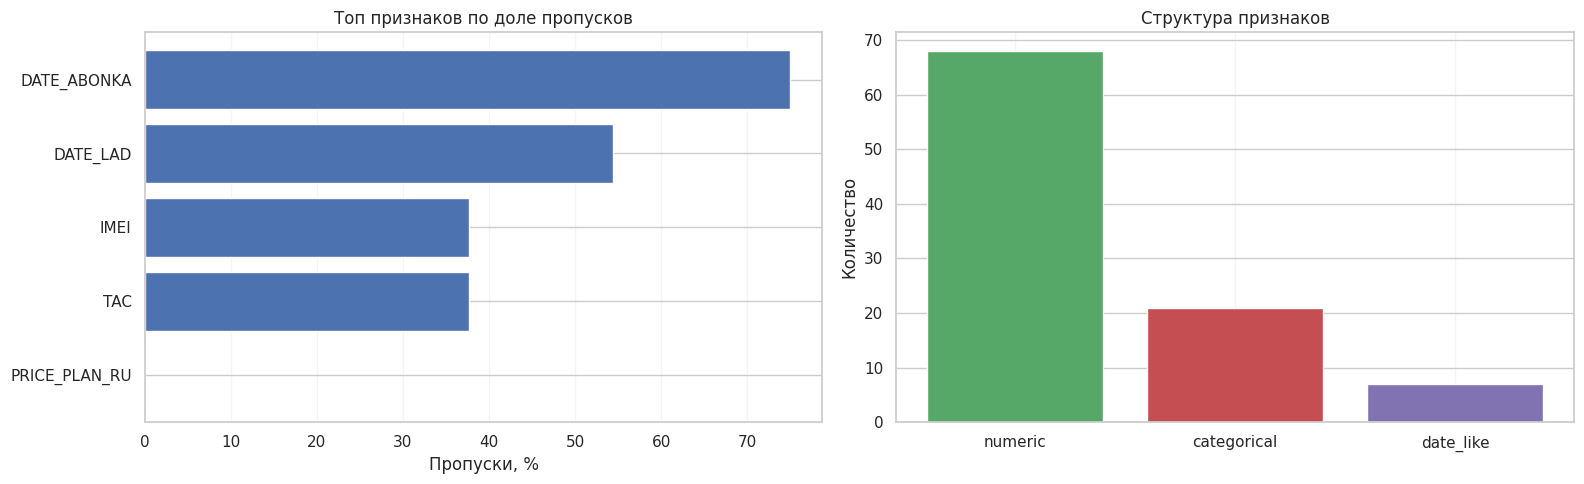

Комментарий: это чистый EDA-ноутбук. Здесь нет логики split-а на контроль/тест.


In [5]:
display(Markdown("## 1. Профиль данных и первичная диагностика"))

source_df = cast_clickhouse_date_columns(df_final, CLICKHOUSE_DATE_FORMAT)
id_col = detect_id_column(source_df)
numeric_cols, categorical_cols, date_like_cols = infer_feature_buckets(source_df, id_col=id_col)
profile_categorical_cols, excluded_categorical_features = select_categorical_features_for_profile(source_df, categorical_cols)
duplicate_id_count = int(source_df[id_col].duplicated().sum())

profile_overview = pd.DataFrame(
    {
        "metric": [
            "Количество строк",
            "Количество столбцов",
            "Идентификатор",
            "Числовые признаки",
            "Категориальные признаки",
            "Категориальные (умеренная кардинальность)",
            "Дата/время признаки (по формату ClickHouse)",
            "Дубликаты по идентификатору",
        ],
        "value": [
            len(source_df),
            source_df.shape[1],
            id_col,
            len(numeric_cols),
            len(categorical_cols),
            len(profile_categorical_cols),
            len(date_like_cols),
            duplicate_id_count,
        ],
    }
)
display(profile_overview)

missing_report = (
    pd.DataFrame(
        {
            "feature": source_df.columns,
            "dtype": [str(source_df[column].dtype) for column in source_df.columns],
            "missing_pct": [source_df[column].isna().mean() * 100 for column in source_df.columns],
            "unique_values": [source_df[column].nunique(dropna=True) for column in source_df.columns],
        }
    )
    .sort_values(["missing_pct", "unique_values"], ascending=[False, False])
    .reset_index(drop=True)
)

constant_features = missing_report.loc[missing_report["unique_values"] <= 1, "feature"].tolist()
high_cardinality_features = missing_report.loc[
    (missing_report["dtype"] == "object") & (missing_report["unique_values"] > MAX_CATEGORY_UNIQUE_VALUES),
    ["feature", "unique_values"],
].head(20)

display(Markdown("### Топ признаков по пропускам"))
display(missing_report.head(20))

if constant_features:
    print(f"Константные признаки: {', '.join(constant_features[:10])}" + (" ..." if len(constant_features) > 10 else ""))
else:
    print("Константных признаков не найдено.")

if duplicate_id_count == 0:
    print(f"Дублей по {id_col} не найдено.")
else:
    print(f"Найдено {duplicate_id_count:,} дублей по {id_col}.")

if not high_cardinality_features.empty:
    display(Markdown("### High-cardinality категориальные признаки"))
    display(high_cardinality_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
missing_plot = missing_report.loc[missing_report["missing_pct"] > 0].head(TOP_MISSING_FEATURES).sort_values("missing_pct", ascending=True)
if not missing_plot.empty:
    axes[0].barh(missing_plot["feature"], missing_plot["missing_pct"], color="#4C72B0")
    axes[0].set_xlabel("Пропуски, %")
else:
    axes[0].text(0.5, 0.5, "Признаков с пропусками нет", ha="center", va="center")
axes[0].set_title("Топ признаков по доле пропусков")
axes[0].set_ylabel("")

type_counts = pd.Series(
    {
        "numeric": len(numeric_cols),
        "categorical": len(categorical_cols),
        "date_like": len(date_like_cols),
    }
)
axes[1].bar(type_counts.index, type_counts.values, color=["#55A868", "#C44E52", "#8172B2"])
axes[1].set_title("Структура признаков")
axes[1].set_ylabel("Количество")
for axis in axes:
    axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

print("Комментарий: это чистый EDA-ноутбук. Здесь нет логики split-а на контроль/тест.")

## 2. Обоснование выбора колонок для UKG split

Здесь формируется методологическое обоснование, какие поля использовать для деления на `control/test`.

Критерии:
- бизнес-смысл и устойчивость во времени
- умеренная кардинальность для strata
- контролируемые пропуски
- отсутствие прямых идентификаторов
- наличие поведенческих сигналов

`Gender` и `Age` исключаем как чувствительные/модельные признаки. Вместо них берем поведенческие прокси:
- `LIFETIME_TOTAL` (сколько абонент с нами)
- `DAYS_WITHOUT_PAYMENT` (давность платного поведения)

In [6]:
selection_catalog = pd.DataFrame(
    [
        ("SUBS_ID", "id", "exclude", "Технический ключ абонента"),
        ("CTN", "id_like", "exclude", "Номер, высокий cardinality"),
        ("IMEI", "id_like", "exclude", "Идентификатор устройства"),
        ("ACTIVE_IND", "binary", "stratify", "Базовый статус активности"),
        ("STATUS", "categorical", "stratify", "Операционный статус абонента"),
        ("CUST_LEVEL", "categorical", "stratify", "Тип клиента"),
        ("REGION", "categorical", "stratify", "Регион с максимальными событиями"),
        ("PERIODICITY", "categorical", "stratify", "Периодичность тарифа"),
        ("FLAG_4G", "binary", "stratify", "4G SIM"),
        ("FLAG_ABONKA", "binary", "stratify", "Факт оплаты абонплаты"),
        ("LIFETIME_TOTAL", "numeric", "ks_check", "Стаж абонента в сети"),
        ("DAYS_WITHOUT_PAYMENT", "numeric", "ks_check", "Дни без платных транзакций"),
        ("REVENUE_TOTAL", "numeric", "ks_check", "Денежная активность"),
        ("TOTAL_RECHARGE", "numeric", "ks_check", "Пополнения"),
        ("BALANCE_END", "numeric", "ks_check", "Баланс на конец периода"),
        ("USAGE_INTERNET", "numeric", "ks_check", "Data usage"),
        ("TOTAL_MOU", "numeric", "ks_check", "Голосовая активность"),
        ("GENDER", "sensitive", "exclude", "Исключаем из split"),
        ("AGE", "sensitive", "exclude", "Исключаем из split"),
    ],
    columns=["column", "type", "recommended_usage", "rationale"],
)

selection_catalog["exists_in_slice"] = selection_catalog["column"].isin(source_df.columns)
selection_catalog["missing_pct"] = selection_catalog["column"].map(
    lambda col: float(source_df[col].isna().mean() * 100) if col in source_df.columns else np.nan
)
selection_catalog["unique_values"] = selection_catalog["column"].map(
    lambda col: int(source_df[col].nunique(dropna=True)) if col in source_df.columns else np.nan
)

selection_catalog["decision"] = np.where(
    selection_catalog["exists_in_slice"],
    selection_catalog["recommended_usage"],
    "not_available",
)

display(Markdown("### Каталог выбора колонок для split"))
display(selection_catalog)

final_strata_cols = selection_catalog.loc[
    (selection_catalog["decision"] == "stratify")
    & (selection_catalog["exists_in_slice"])
    & (selection_catalog["missing_pct"] <= 35)
    & (selection_catalog["unique_values"] <= 100),
    "column",
].tolist()

final_ks_cols = selection_catalog.loc[
    (selection_catalog["decision"] == "ks_check")
    & (selection_catalog["exists_in_slice"]),
    "column",
].tolist()

display(Markdown("### Итоговые колонки для передачи в split-ноутбук"))
print("strata:", ", ".join(final_strata_cols) if final_strata_cols else "нет")
print("ks_check:", ", ".join(final_ks_cols) if final_ks_cols else "нет")

### Каталог выбора колонок для split

,column,type,recommended_usage,rationale,exists_in_slice,missing_pct,unique_values,decision
0,SUBS_ID,id,exclude,Технический ключ абонента,True,0.0000,2921367,exclude
1,CTN,id_like,exclude,"Номер, высокий cardinality",True,0.0000,2921232,exclude
2,IMEI,id_like,exclude,Идентификатор устройства,True,37.6606,1693815,exclude
3,ACTIVE_IND,binary,stratify,Базовый статус активности,True,0.0000,4,stratify
4,STATUS,categorical,stratify,Операционный статус абонента,True,0.0000,4,stratify
5,CUST_LEVEL,categorical,stratify,Тип клиента,True,0.0000,4,stratify
6,REGION,categorical,stratify,Регион с максимальными событиями,True,0.0000,11,stratify
7,PERIODICITY,categorical,stratify,Периодичность тарифа,True,0.0000,7,stratify
8,FLAG_4G,binary,stratify,4G SIM,True,0.0000,2,stratify
9,FLAG_ABONKA,binary,stratify,Факт оплаты абонплаты,True,0.0000,2,stratify


### Итоговые колонки для передачи в split-ноутбук

strata: ACTIVE_IND, STATUS, CUST_LEVEL, REGION, PERIODICITY, FLAG_4G, FLAG_ABONKA
ks_check: LIFETIME_TOTAL, DAYS_WITHOUT_PAYMENT, REVENUE_TOTAL, TOTAL_RECHARGE, BALANCE_END, USAGE_INTERNET, TOTAL_MOU


## 3. Графики по выбранным колонкам

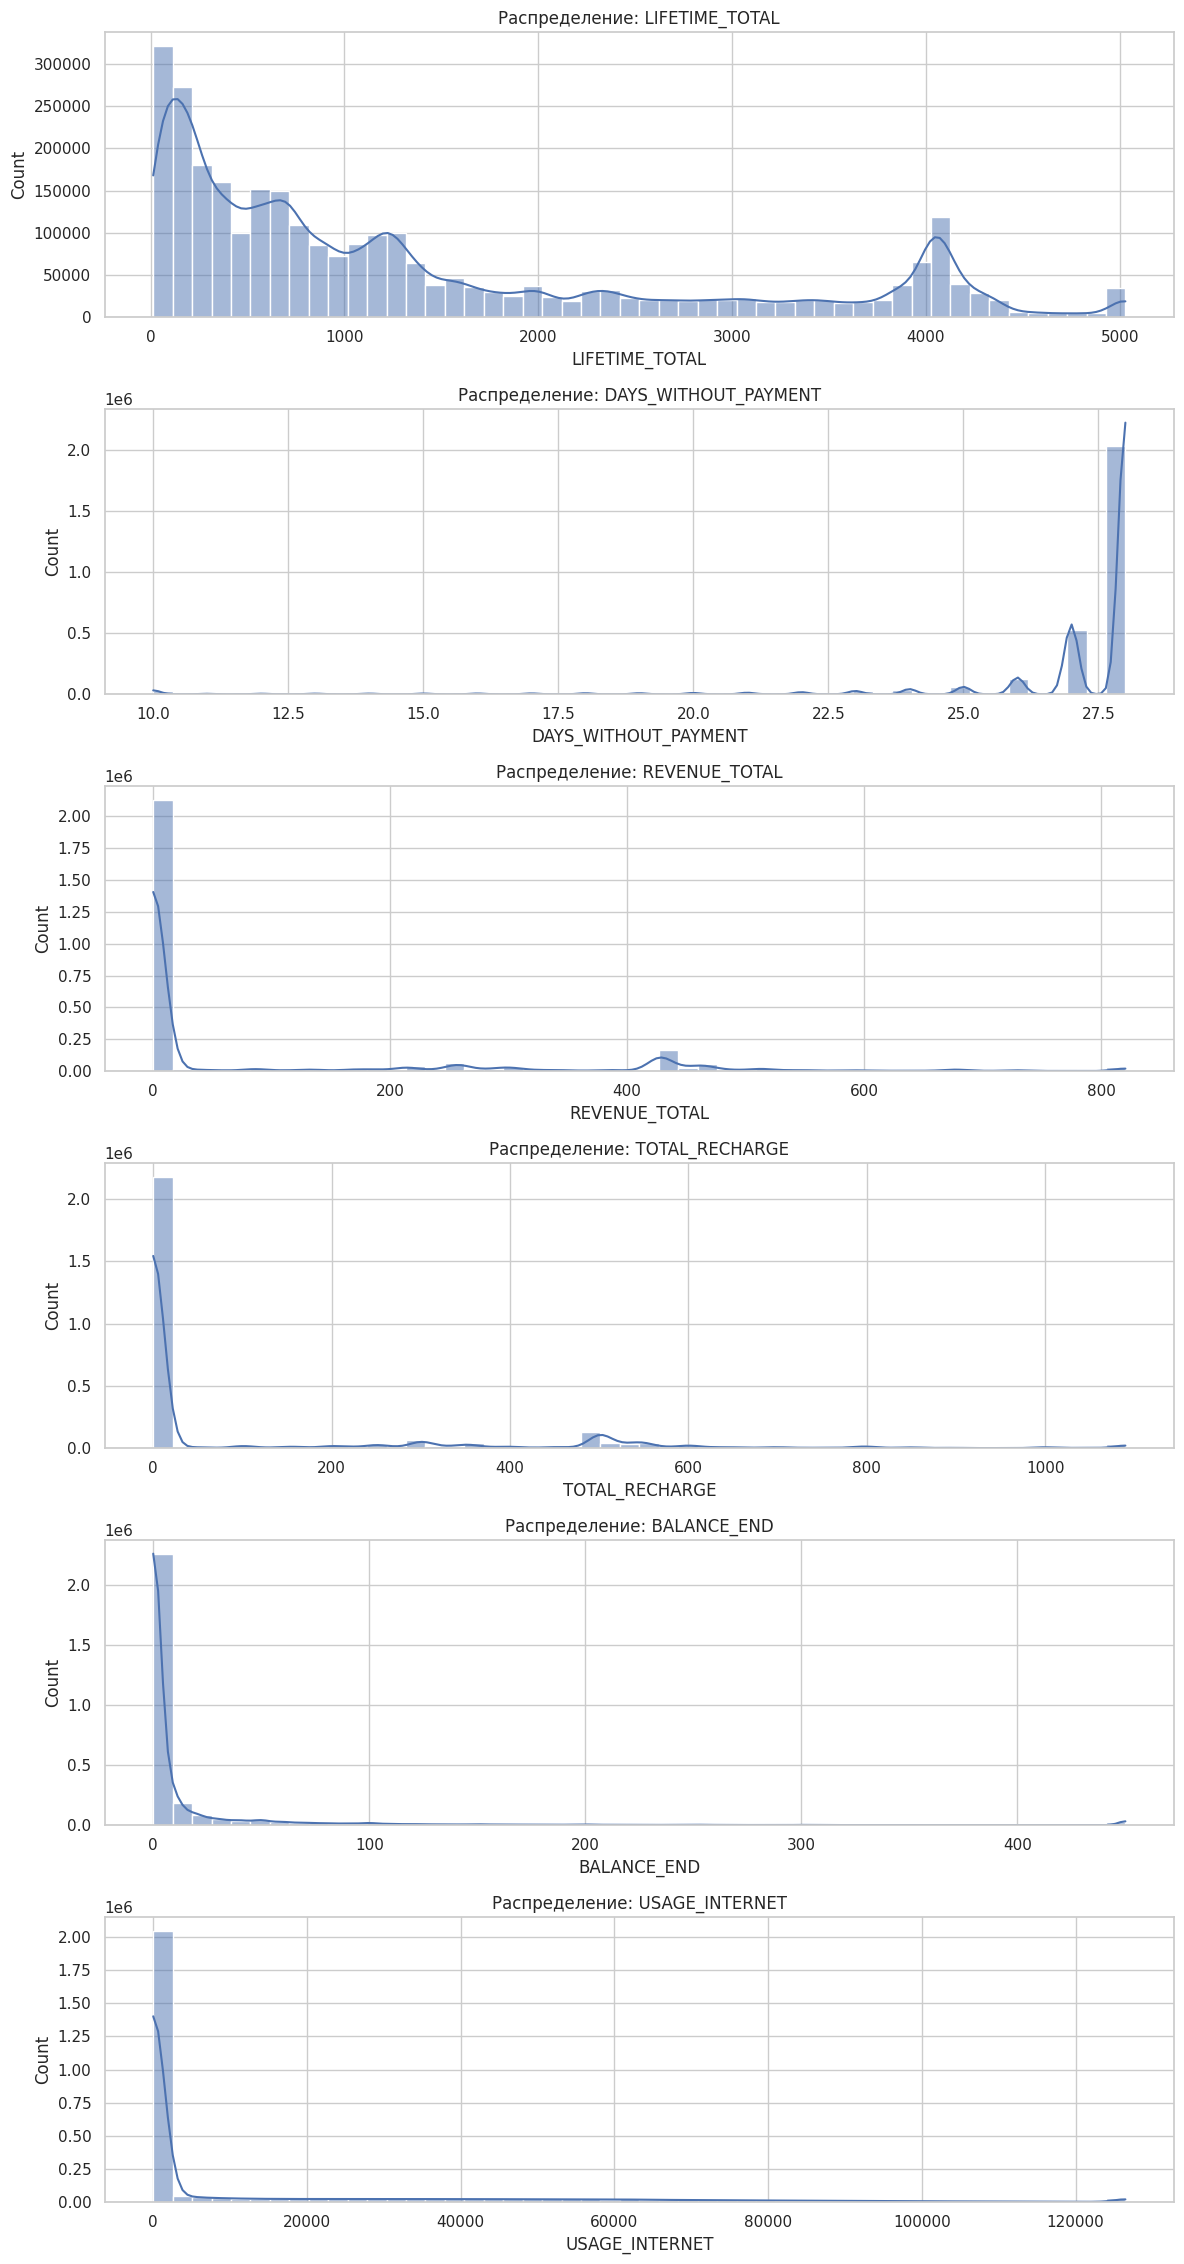

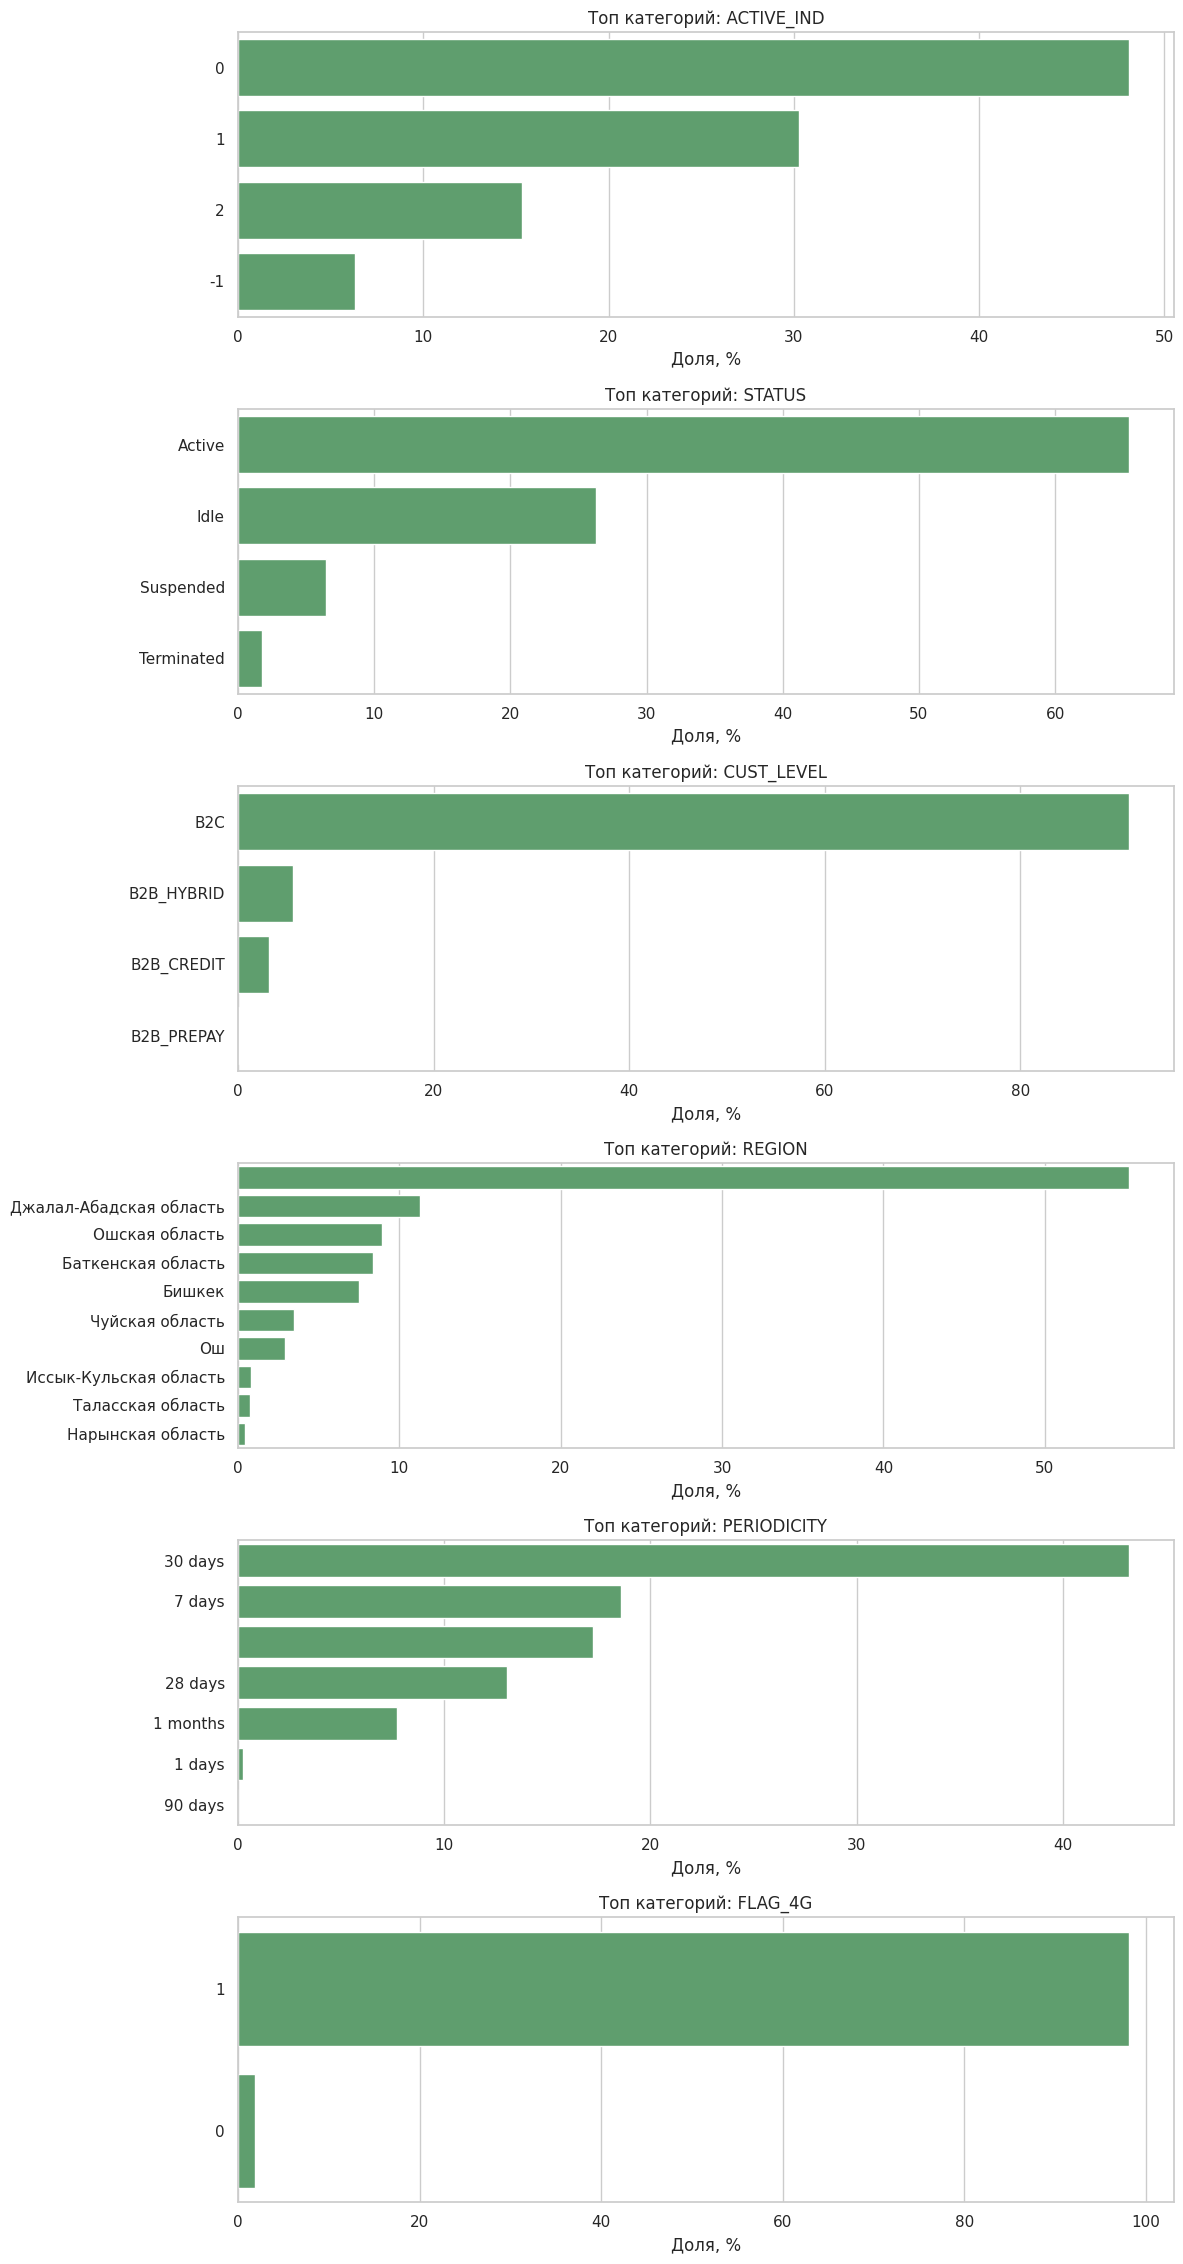

Комментарий: эти распределения помогают обосновать выбор колонок для split-политики до применения алгоритма разбиения.


In [7]:
display(Markdown("## 3. Графики по выбранным колонкам"))

eda_numeric_cols = [col for col in final_ks_cols if col in source_df.columns and pd.api.types.is_numeric_dtype(source_df[col])]
eda_cat_cols = [col for col in final_strata_cols if col in source_df.columns]

if eda_numeric_cols:
    num_cols = eda_numeric_cols[: min(6, len(eda_numeric_cols))]
    fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 3.8 * len(num_cols)))
    if len(num_cols) == 1:
        axes = [axes]

    for axis, col in zip(axes, num_cols):
        plot_df = source_df[[col]].dropna().copy()
        if plot_df.empty:
            axis.text(0.5, 0.5, f"Нет данных для {col}", ha="center", va="center")
            continue
        low, high = plot_df[col].quantile([0.01, 0.99])
        plot_df[col] = plot_df[col].clip(lower=low, upper=high)
        sns.histplot(plot_df[col], bins=50, kde=True, color="#4C72B0", ax=axis)
        axis.set_title(f"Распределение: {col}")
        axis.set_xlabel(col)
    plt.tight_layout()
    plt.show()

if eda_cat_cols:
    cat_cols = eda_cat_cols[: min(6, len(eda_cat_cols))]
    fig, axes = plt.subplots(len(cat_cols), 1, figsize=(12, 3.8 * len(cat_cols)))
    if len(cat_cols) == 1:
        axes = [axes]

    for axis, col in zip(axes, cat_cols):
        cat_series = source_df[col].astype("string").fillna("MISSING")
        top = cat_series.value_counts(normalize=True).head(10).mul(100)
        sns.barplot(x=top.values, y=top.index, color="#55A868", ax=axis)
        axis.set_title(f"Топ категорий: {col}")
        axis.set_xlabel("Доля, %")
        axis.set_ylabel("")
    plt.tight_layout()
    plt.show()

print("Комментарий: эти распределения помогают обосновать выбор колонок для split-политики до применения алгоритма разбиения.")

## 4. Выводы

Ключевые выводы этого EDA:
- качество данных и структура признаков проверены на месячном срезе
- выбран набор колонок для split без чувствительных признаков `Gender` и `Age`
- рекомендованные `strata` и `ks_check` колонки зафиксированы для передачи в split-ноутбук

In [8]:
eda_conclusion = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "id_column",
            "duplicate_ids",
            "numeric_features",
            "categorical_features",
            "date_like_features",
            "recommended_strata_cols",
            "recommended_ks_cols",
        ],
        "value": [
            len(source_df),
            source_df.shape[1],
            id_col,
            duplicate_id_count,
            len(numeric_cols),
            len(categorical_cols),
            len(date_like_cols),
            ", ".join(final_strata_cols),
            ", ".join(final_ks_cols),
        ],
    }
)

display(Markdown("### Итоговая сводка EDA"))
display(eda_conclusion)
print("Итог: EDA завершен, набор колонок для split обоснован и передан в split-ноутбук.")

### Итоговая сводка EDA

,metric,value
0,rows,2921367
1,columns,97
2,id_column,SUBS_ID
3,duplicate_ids,0
4,numeric_features,68
5,categorical_features,21
6,date_like_features,7
7,recommended_strata_cols,"ACTIVE_IND, STATUS, CUST_LEVEL, REGION, PERIOD..."
8,recommended_ks_cols,"LIFETIME_TOTAL, DAYS_WITHOUT_PAYMENT, REVENUE_..."


Итог: EDA завершен, набор колонок для split обоснован и передан в split-ноутбук.


## 5. Полноценный Feature EDA (срез за один месяц)

Ниже строится feature-level обзор по **каждой колонке**:
- описание фичи (из ORM-комментариев)
- формат и тип данных
- пропуски, кардинальность, доля нулей
- выбросы (IQR и z-score)
- shape распределения (скошенность, kurtosis)
- рекомендации по использованию в модели

Важно: срез за один месяц не позволяет проверить сезонность/стабильность во времени, поэтому рекомендации касаются только quality и формы распределения текущего периода.

In [9]:
FEATURE_EDA_SAMPLE = 300_000
Z_OUTLIER_THRESHOLD = 3.0


def infer_feature_family(column: str, series: pd.Series) -> str:
    upper = column.upper()
    if upper in {"SUBS_ID", "CTN", "IMEI", "TAC", "CELL_ID", "CELL_MAX"}:
        return "identifier_or_device"
    if upper in CLICKHOUSE_DATE_FORMAT:
        return "date_or_datetime"
    if pd.api.types.is_numeric_dtype(series):
        uniq = series.nunique(dropna=True)
        if uniq <= 2:
            return "binary_numeric"
        return "numeric"
    return "categorical"



def recommend_model_usage_ru(feature_family: str, missing_pct: float, unique_values: int, column: str) -> str:
    upper = column.upper()
    if feature_family == "identifier_or_device":
        return "Не использовать как обычную модельную фичу; оставить только для joins, аудита и контроля дублей."
    if feature_family == "date_or_datetime":
        return "Не подавать сырую дату в модель; лучше строить recency/tenure/day-delta признаки."
    if feature_family == "binary_numeric":
        return "Можно использовать напрямую как бинарный флаг; важно проверять дисбаланс классов и drift."
    if feature_family == "categorical":
        if unique_values > 200:
            return "Высокая кардинальность: нужен rare-bucketing, frequency encoding или target encoding с защитой от leakage."
        return "Подходит для one-hot/frequency encoding; пропуски лучше оставить отдельным уровнем MISSING."
    if missing_pct > 40:
        return "Высокая доля пропусков: использовать осторожно, добавить missing-indicator и устойчивую импутацию."
    if upper in {"REVENUE_TOTAL", "TOTAL_RECHARGE", "BALANCE_END", "USAGE_INTERNET", "TOTAL_MOU", "GM"}:
        return "Сильный поведенческий сигнал; желательно log1p, clip/winsorize хвостов и контроль выбросов."
    return "Можно использовать как numeric; желательно проверить scaling, winsorization и устойчивость по нескольким месяцам."



def get_outlier_stats(numeric: pd.Series) -> tuple[float, float]:
    clean = pd.to_numeric(numeric, errors="coerce").dropna()
    if len(clean) < 20:
        return np.nan, np.nan

    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        iqr_rate = 0.0
    else:
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        iqr_rate = float(((clean < low) | (clean > high)).mean() * 100)

    std = clean.std(ddof=0)
    if std == 0 or np.isnan(std):
        z_rate = 0.0
    else:
        z_rate = float((np.abs((clean - clean.mean()) / std) > Z_OUTLIER_THRESHOLD).mean() * 100)
    return iqr_rate, z_rate



def get_date_sentinel_stats(series: pd.Series) -> tuple[float, str, str]:
    dt = pd.to_datetime(series, errors="coerce")
    if dt.notna().sum() == 0:
        return np.nan, "", ""

    sentinel_mask = dt.dt.strftime("%Y-%m-%d").eq("1970-01-01")
    sentinel_pct = float(sentinel_mask.mean() * 100)
    min_dt = str(dt.min().date()) if pd.notna(dt.min()) else ""
    max_dt = str(dt.max().date()) if pd.notna(dt.max()) else ""
    return sentinel_pct, min_dt, max_dt


eda_df = source_df.copy()
eda_sample = eda_df.sample(FEATURE_EDA_SAMPLE, random_state=42) if len(eda_df) > FEATURE_EDA_SAMPLE else eda_df.copy()

feature_rows = []
for column in eda_df.columns:
    series = eda_df[column]
    family = infer_feature_family(column, series)
    missing_pct = float(series.isna().mean() * 100)
    unique_values = int(series.nunique(dropna=True))

    row = {
        "Фича": column,
        "Описание": EXCEL_FEATURE_COMMENTS.get(column, "Описание не заполнено"),
        "Домен": infer_business_domain(column),
        "Семейство": family,
        "Тип_данных": str(series.dtype),
        "Пропуски_%": missing_pct,
        "Уникальных_значений": unique_values,
        "Рекомендация_для_модели": recommend_model_usage_ru(family, missing_pct, unique_values, column),
        "Ограничение_среза": "Один месяц: стабильность во времени не проверена.",
    }

    if family in {"numeric", "binary_numeric"}:
        num_full = pd.to_numeric(series, errors="coerce")
        num_sample = pd.to_numeric(eda_sample[column], errors="coerce")
        iqr_out, z_out = get_outlier_stats(num_sample)
        row.update(
            {
                "Нулей_%": float((num_full == 0).mean() * 100),
                "Среднее": float(num_full.mean()),
                "Std": float(num_full.std()),
                "P01": float(num_full.quantile(0.01)),
                "P50": float(num_full.quantile(0.50)),
                "P99": float(num_full.quantile(0.99)),
                "Min": float(num_full.min()),
                "Max": float(num_full.max()),
                "Skew_sample": float(num_sample.dropna().skew()) if num_sample.notna().sum() > 3 else np.nan,
                "Kurtosis_sample": float(num_sample.dropna().kurt()) if num_sample.notna().sum() > 3 else np.nan,
                "Выбросы_IQR_%_sample": iqr_out,
                "Выбросы_Z3_%_sample": z_out,
            }
        )
    elif family == "date_or_datetime":
        sentinel_pct, min_dt, max_dt = get_date_sentinel_stats(series)
        row.update(
            {
                "Дата_1970_%": sentinel_pct,
                "Min_date": min_dt,
                "Max_date": max_dt,
            }
        )
    else:
        top_values = series.astype("string").fillna("MISSING").value_counts(normalize=True).head(5)
        row["Топ_уровни"] = "; ".join([f"{idx}:{val:.2%}" for idx, val in top_values.items()])

    feature_rows.append(row)

feature_eda_report = pd.DataFrame(feature_rows)
feature_eda_report = feature_eda_report.sort_values(["Семейство", "Пропуски_%", "Уникальных_значений"], ascending=[True, False, False]).reset_index(drop=True)

display(Markdown("### Полный feature passport по всем колонкам"))
display(feature_eda_report)

report_path = path_config.data_processed_path / f"feature_eda_report_{DATA_START}.csv"
feature_eda_report.to_csv(report_path, index=False)
print(f"Feature EDA report сохранен: {report_path}")

### Полный feature passport по всем колонкам

,Фича,Описание,Домен,Семейство,Тип_данных,Пропуски_%,Уникальных_значений,Рекомендация_для_модели,Ограничение_среза,Дата_1970_%,Min_date,Max_date,Топ_уровни,Нулей_%,Среднее,Std,P01,P50,P99,Min,Max,Skew_sample,Kurtosis_sample,Выбросы_IQR_%_sample,Выбросы_Z3_%_sample
0,TRANZ_FLAG,Флаг наличия платного события в расчетном пери...,flags,binary_numeric,uint8,0.0000,2,Можно использовать напрямую как бинарный флаг;...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,71.3332,0.2867,0.4522,0.0000,0.0000,1.0000,0.0000,1.0000,0.9438,-1.1092,0.0000,0.0000
1,FLAG_4G,Флаг наличия SIM-карты с поддержкой 4G.,technology,binary_numeric,uint8,0.0000,2,Можно использовать напрямую как бинарный флаг;...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,1.8241,0.9818,0.1338,0.0000,1.0000,1.0000,0.0000,1.0000,-7.2212,50.1461,0.0000,1.8140
2,FLAG_ABONKA,"Флаг абонента, оплатившего хотя бы одну абонпл...",flags,binary_numeric,uint8,0.0000,2,Можно использовать напрямую как бинарный флаг;...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,74.9826,0.2502,0.4331,0.0000,0.0000,1.0000,0.0000,1.0000,1.1504,-0.6766,0.0000,0.0000
3,FIRST_SIM,Флаг первосимочника.,flags,binary_numeric,uint8,0.0000,2,Можно использовать напрямую как бинарный флаг;...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,80.4736,0.1953,0.3964,0.0000,0.0000,1.0000,0.0000,1.0000,1.5377,0.3646,0.0000,0.0000
4,MY_BEELINE_USER,Флаг пользователя My Beeline.,flags,binary_numeric,uint8,0.0000,2,Можно использовать напрямую как бинарный флаг;...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,84.2753,0.1572,0.3640,0.0000,0.0000,1.0000,0.0000,1.0000,1.8758,1.5186,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,DAYS_WITHOUT_PAYMENT,Количество дней без исходящих платных транзакций.,other,numeric,int64,0.0000,29,Можно использовать как numeric; желательно про...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,0.2022,27.0547,2.9901,10.0000,28.0000,28.0000,0.0000,28.0000,-5.7640,38.4866,8.0377,2.4253
93,USAGE_DAILY_ABONKA,Количество списаний ежедневной абонплаты.,usage,numeric,uint64,0.0000,16,Можно использовать как numeric; желательно про...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,99.9197,0.0014,0.0635,0.0000,0.0000,0.0000,0.0000,18.0000,60.5027,"4,778.4994",0.0000,0.0833
94,USAGE_NUM_INTERNET_PAK,Количество приобретенных интернет-пакетов.,usage,numeric,uint64,0.0000,9,Можно использовать как numeric; желательно про...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,99.8886,0.0013,0.0428,0.0000,0.0000,0.0000,0.0000,15.0000,56.0576,"5,225.4006",0.0000,0.1103
95,REVENUE_OFFNET_PAK,Списания за пакеты минут вне сети.,finance,numeric,float64,0.0000,4,Можно использовать как numeric; желательно про...,Один месяц: стабильность во времени не проверена.,NaN,NaN,NaN,NaN,99.9986,0.0015,0.4317,0.0000,0.0000,0.0000,0.0000,230.7692,271.8537,"76,526.9750",0.0000,0.0017


Feature EDA report сохранен: /data/aturov/universal_control_group/data/processed/feature_eda_report_2026-02-01.csv


In [10]:
risk_view = feature_eda_report.copy()

high_missing = risk_view.loc[risk_view["Пропуски_%"] >= 30, ["Фича", "Описание", "Пропуски_%", "Рекомендация_для_модели"]]
strong_outliers = risk_view.loc[
    risk_view["Выбросы_IQR_%_sample"].fillna(0) >= 5,
    ["Фича", "Описание", "Выбросы_IQR_%_sample", "P01", "P50", "P99", "Max"],
].sort_values("Выбросы_IQR_%_sample", ascending=False)
strong_skew = risk_view.loc[
    risk_view["Skew_sample"].abs().fillna(0) >= 2,
    ["Фича", "Описание", "Skew_sample", "P01", "P50", "P99", "Max"],
].sort_values("Skew_sample", key=lambda s: s.abs(), ascending=False)
problem_dates = risk_view.loc[
    risk_view["Дата_1970_%"].fillna(0) > 0,
    ["Фича", "Описание", "Дата_1970_%", "Min_date", "Max_date"],
].sort_values("Дата_1970_%", ascending=False)

risk_summary = pd.DataFrame(
    {
        "метрика": [
            "Фичи с пропусками >= 30%",
            "Фичи с выбросами IQR >= 5%",
            "Фичи с |skew| >= 2",
            "Дата-поля с 1970-01-01",
        ],
        "количество": [
            len(high_missing),
            len(strong_outliers),
            len(strong_skew),
            len(problem_dates),
        ],
    }
)

display(Markdown("### Сводка по основным рискам качества данных"))
display(risk_summary)

display(Markdown("### Фичи с высокой долей пропусков"))
display(high_missing.head(30))

display(Markdown("### Фичи с наиболее выраженными выбросами"))
display(strong_outliers.head(30))

display(Markdown("### Фичи с сильной асимметрией"))
display(strong_skew.head(30))

display(Markdown("### Датовые поля с признаком заглушки 1970-01-01"))
display(problem_dates.head(30))

### Сводка по основным рискам качества данных

,метрика,количество
0,Фичи с пропусками >= 30%,4
1,Фичи с выбросами IQR >= 5%,25
2,Фичи с |skew| >= 2,58
3,Дата-поля с 1970-01-01,2


### Фичи с высокой долей пропусков

,Фича,Описание,Пропуски_%,Рекомендация_для_модели
25,DATE_ABONKA,Дата последнего списания абонентской платы.,74.9826,Не подавать сырую дату в модель; лучше строить...
26,DATE_LAD,Дата последнего активного действия абонента.,54.4162,Не подавать сырую дату в модель; лучше строить...
32,IMEI,IMEI устройства.,37.6606,Не использовать как обычную модельную фичу; ос...
33,TAC,Первые 8 символов IMEI телефона.,37.6606,Не использовать как обычную модельную фичу; ос...


### Фичи с наиболее выраженными выбросами

,Фича,Описание,Выбросы_IQR_%_sample,P01,P50,P99,Max
50,INTERCONNECT_LOC_OUT,Расходы по исходящему локальному интерконнекту.,24.2913,-66.1833,0.0000,0.0000,107.8750
78,REVENUE_ABONKA,Сумма списаний за абонентскую плату.,23.9327,0.0000,0.0000,726.4957,"7,076.9231"
56,TOTAL_RECHARGE,Общая сумма пополнений за расчетный период.,23.6027,0.0000,0.0000,"1,090.0000","307,899.0000"
53,USAGE_OUT_ONNET_VOICE,"Исходящий внутрисетевой voice-трафик, минуты.",23.1807,0.0000,0.0000,192.3057,"29,024.2667"
42,USAGE_INTERNET_NIGHT,Ночной интернет-трафик.,21.9727,0.0000,0.0000,"14,493.0763","2,430,654.6555"
68,USAGE_IN_OFFNET_O_VOICE,Входящий трафик с номеров O!.,20.8370,0.0000,0.0000,39.0667,"32,195.7333"
49,REVENUE_TOTAL,Общая сумма списаний с баланса включая коррект...,20.5627,0.0000,0.0000,820.5129,"191,228.1113"
83,USAGE_NUM_OUT,Количество исходящих звонков за период.,19.8083,0.0000,0.0000,168.0000,"87,882.0000"
57,USAGE_OUT_OFFNET_VOICE,"Исходящий трафик на сети конкурентов, минуты.",19.2030,0.0000,0.0000,67.3500,"84,648.2167"
54,USAGE_IN_ONNET_VOICE,"Входящий внутрисетевой трафик, минуты.",19.1377,0.0000,0.0000,168.4833,"227,505.3667"


### Фичи с сильной асимметрией

,Фича,Описание,Skew_sample,P01,P50,P99,Max
85,COUNT_SMS,Количество SMS за период.,539.8791,0.0000,0.0000,9.0000,"89,612.0000"
54,USAGE_IN_ONNET_VOICE,"Входящий внутрисетевой трафик, минуты.",538.1824,0.0000,0.0000,168.4833,"227,505.3667"
82,USAGE_NUM_INC,Количество входящих звонков.,508.2945,0.0000,0.0000,155.0000,"107,802.0000"
52,TOTAL_MOU,Сумма минут внутри КР.,500.5176,0.0000,0.0000,405.1000,"231,803.3167"
66,REVENUE_OFFNET_MEGACOM_VOICE,Списания за исходящий трафик на номера MegaCom.,331.9491,0.0000,0.0000,2.5641,"44,325.5022"
95,REVENUE_OFFNET_PAK,Списания за пакеты минут вне сети.,271.8537,0.0000,0.0000,0.0000,230.7692
74,REVENUE_OUT_CITY_VOICE,Списания за звонки на фиксированные сети КР.,267.1999,0.0000,0.0000,0.0000,"1,382.8509"
64,REVENUE_OFFNET_O_VOICE,Списания за исходящий трафик на номера O!.,250.2786,0.0000,0.0000,5.1282,"102,944.3034"
62,REVENUE_OUT_OFFNET_VOICE,Списания за звонки на других операторов КР.,225.8211,0.0000,0.0000,9.2749,"134,572.5072"
55,REVENUE_VOICE,Списания за voice-услуги.,199.7798,0.0000,0.0000,30.3744,"159,390.5044"


### Датовые поля с признаком заглушки 1970-01-01

,Фича,Описание,Дата_1970_%,Min_date,Max_date
30,DATE_INACTIVE,Дата перехода в неактивный статус.,37.6606,1970-01-01,2026-05-29
29,PRICE_CHANGE_DATE,Дата последней смены тарифного плана.,0.0000,1970-01-01,2026-02-27


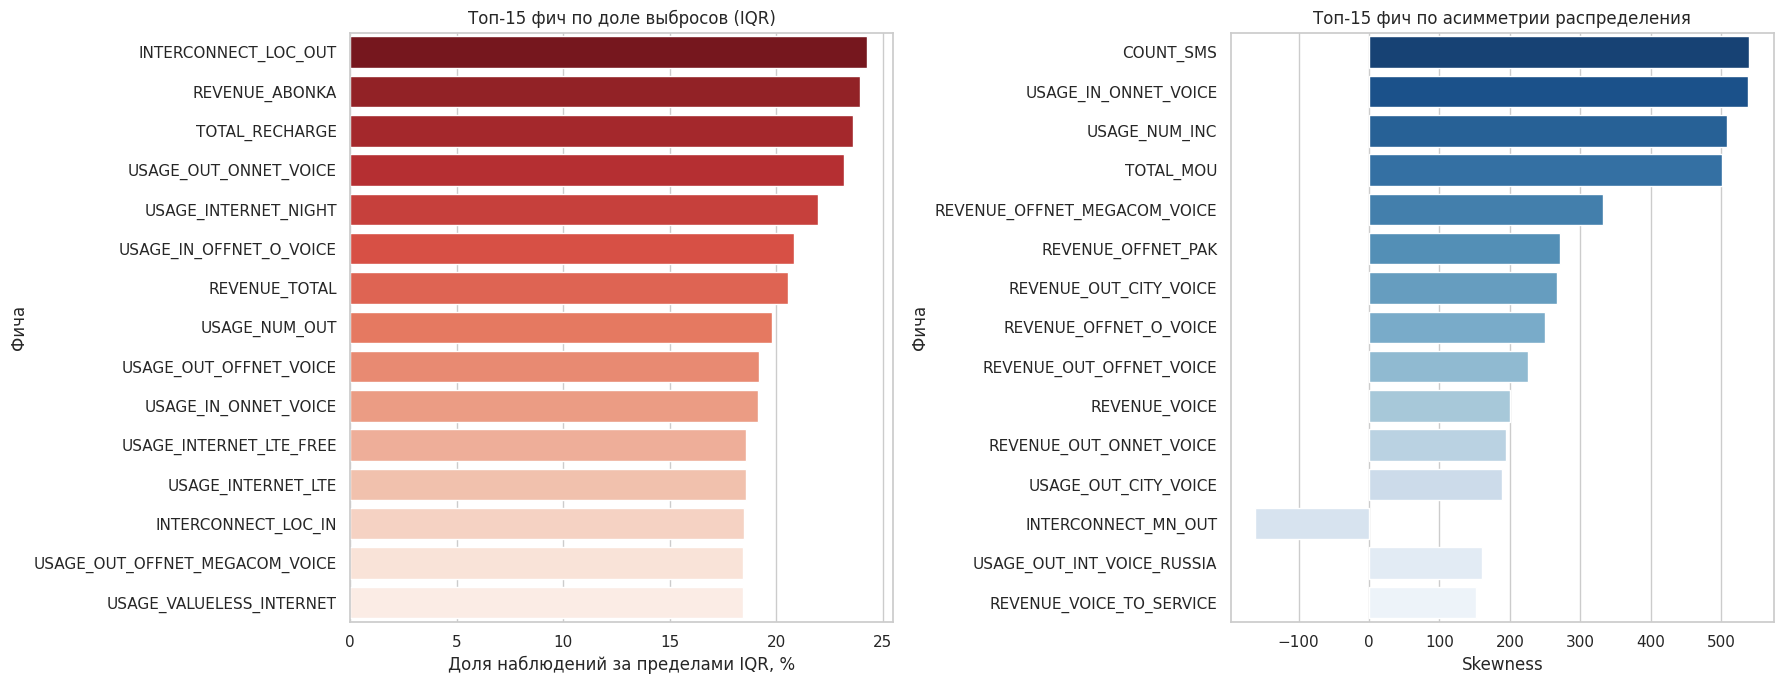

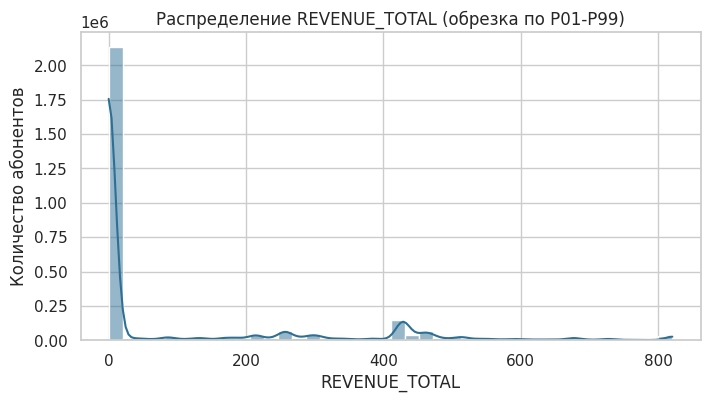

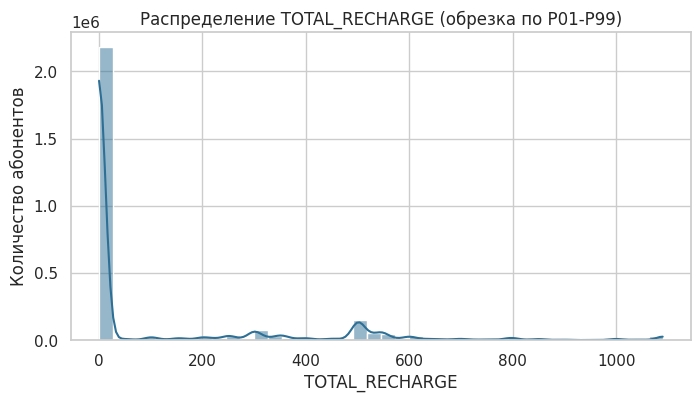

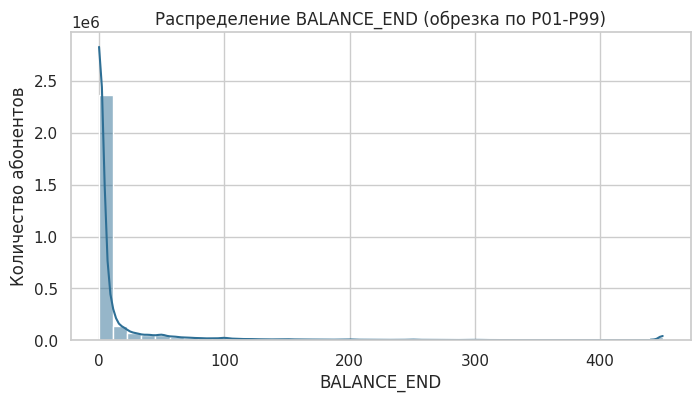

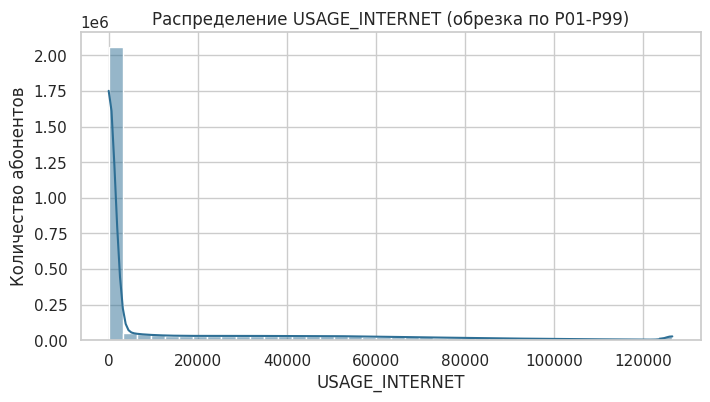

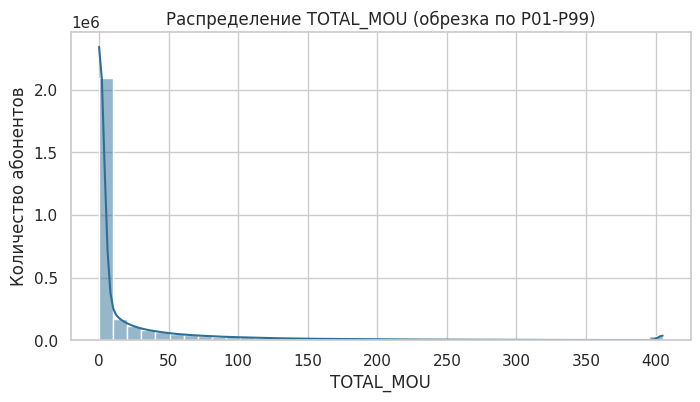

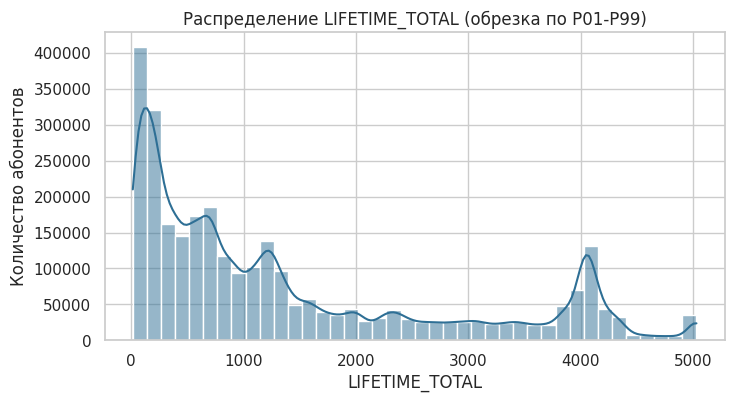

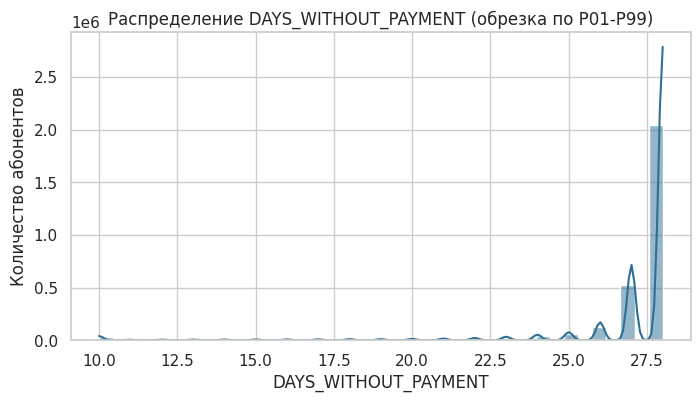

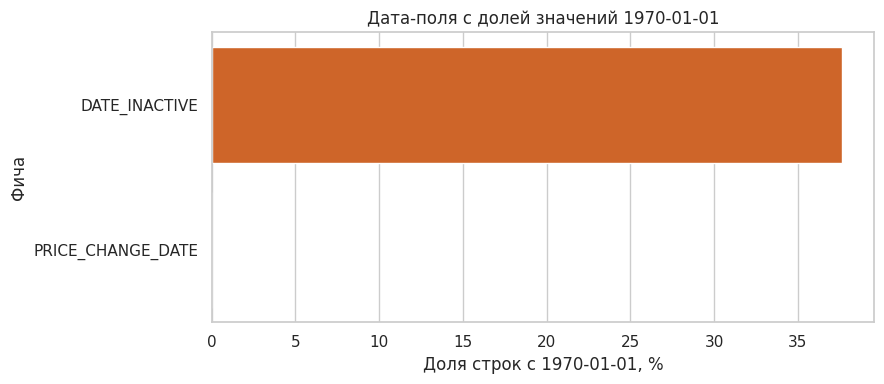

In [11]:
plot_outliers = (
    feature_eda_report.loc[feature_eda_report["Выбросы_IQR_%_sample"].notna(), ["Фича", "Описание", "Выбросы_IQR_%_sample"]]
    .sort_values("Выбросы_IQR_%_sample", ascending=False)
    .head(15)
)

plot_skew = (
    feature_eda_report.loc[feature_eda_report["Skew_sample"].notna(), ["Фича", "Описание", "Skew_sample"]]
    .assign(abs_skew=lambda df: df["Skew_sample"].abs())
    .sort_values("abs_skew", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=plot_outliers, y="Фича", x="Выбросы_IQR_%_sample", palette="Reds_r", ax=axes[0])
axes[0].set_title("Топ-15 фич по доле выбросов (IQR)")
axes[0].set_xlabel("Доля наблюдений за пределами IQR, %")
axes[0].set_ylabel("Фича")

sns.barplot(data=plot_skew, y="Фича", x="Skew_sample", palette="Blues_r", ax=axes[1])
axes[1].set_title("Топ-15 фич по асимметрии распределения")
axes[1].set_xlabel("Skewness")
axes[1].set_ylabel("Фича")

plt.tight_layout()
plt.show()

selected_numeric = [
    column
    for column in [
        "REVENUE_TOTAL",
        "TOTAL_RECHARGE",
        "BALANCE_END",
        "USAGE_INTERNET",
        "TOTAL_MOU",
        "LIFETIME_TOTAL",
        "DAYS_WITHOUT_PAYMENT",
    ]
    if column in source_df.columns
]

for column in selected_numeric:
    sample_series = pd.to_numeric(source_df[column], errors="coerce").dropna()
    if sample_series.empty:
        continue
    clipped = sample_series.clip(sample_series.quantile(0.01), sample_series.quantile(0.99))
    plt.figure(figsize=(8, 4))
    sns.histplot(clipped, bins=40, kde=True, color="#2E6F95")
    plt.title(f"Распределение {column} (обрезка по P01-P99)")
    plt.xlabel(column)
    plt.ylabel("Количество абонентов")
    plt.show()

problem_dates_plot = feature_eda_report.loc[
    feature_eda_report["Дата_1970_%"].fillna(0) > 0,
    ["Фича", "Дата_1970_%"],
].sort_values("Дата_1970_%", ascending=False).head(10)

if not problem_dates_plot.empty:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=problem_dates_plot, y="Фича", x="Дата_1970_%", palette="Oranges_r")
    plt.title("Дата-поля с долей значений 1970-01-01")
    plt.xlabel("Доля строк с 1970-01-01, %")
    plt.ylabel("Фича")
    plt.tight_layout()
    plt.show()

## 6. Практический вывод: split, моделирование и feature engineering

Ниже собран прикладной итог EDA:
- какие колонки использовать для split на контрольную группу;
- какие колонки можно использовать в модель напрямую или после трансформации;
- где особенно уместен feature engineering;
- какие признаки лучше не использовать в raw-виде.

Важно:
- рекомендации для split относятся к текущему месячному срезу;
- рекомендации по динамике и трендам требуют нескольких последовательных месячных срезов.

In [12]:
split_feature_summary = (
    selection_catalog.loc[
        selection_catalog["decision"].isin(["stratify", "ks_check"]),
        ["column", "decision", "type", "rationale", "missing_pct", "unique_values"],
    ]
    .rename(
        columns={
            "column": "Фича",
            "decision": "Роль_в_split",
            "type": "Тип",
            "rationale": "Почему_берем",
            "missing_pct": "Пропуски_%",
            "unique_values": "Уникальных_значений",
        }
    )
    .merge(
        feature_dictionary.rename(columns={"feature": "Фича", "описание": "Описание", "тип_в_срезе": "Формат"})[
            ["Фича", "Описание", "Формат", "домен"]
        ],
        on="Фича",
        how="left",
    )
)
split_feature_summary["Практический_комментарий"] = split_feature_summary["Роль_в_split"].map(
    {
        "stratify": "Использовать для strata при детерминированном split, так как признак устойчивый и с умеренной кардинальностью.",
        "ks_check": "Не использовать для strata напрямую, но обязательно контролировать баланс распределений между control/test через KS.",
    }
)


def classify_modeling_action(row: pd.Series) -> str:
    family = row.get("Семейство", "")
    missing = row.get("Пропуски_%", 0.0)
    unique_values = row.get("Уникальных_значений", 0)
    feature = row.get("Фича", "")

    if feature in {"GENDER", "AGE"}:
        return "exclude_sensitive"
    if family == "identifier_or_device":
        return "exclude_identifier"
    if family == "date_or_datetime":
        return "transform_to_recency"
    if unique_values <= 1:
        return "exclude_constant"
    if family == "categorical" and unique_values > 200:
        return "transform_high_cardinality"
    if missing >= 40:
        return "use_with_missing_flag"
    if family in {"numeric", "binary_numeric", "categorical"}:
        return "use_in_model"
    return "review_manually"



def get_feature_engineering_idea(feature: str, domain: str, family: str) -> str:
    upper = feature.upper()
    if upper in {"ACT_DATE", "DATE_CONTRACT", "DATE_LAD", "DATE_ABONKA", "PRICE_CHANGE_DATE", "DATE_INACTIVE"}:
        return "Построить recency/tenure признаки: дней с активации, дней с последней оплаты, дней с последней активности, дней после смены тарифа."
    if upper in {"DAYS_WITHOUT_PAYMENT", "TOTAL_RECHARGE", "COUNT_RECHARGE", "REVENUE_TOTAL", "REVENUE_ABONKA", "BALANCE_END"}:
        return "При нескольких месячных срезах считать лаги, дельты, rolling mean, rolling std, тренд и признаки ускорения/замедления платежного поведения."
    if upper in {"USAGE_INTERNET", "USAGE_INTERNET_LTE", "USAGE_INTERNET_3G", "USAGE_INTERNET_2G", "TOTAL_MOU", "COUNT_SMS", "USAGE_NUM_OUT", "USAGE_NUM_INC"}:
        return "Сделать поведенческие тренды: рост/падение usage month-over-month, volatility, share LTE, internet-to-voice ratio, usage per active day."
    if upper in {"PRICE_PLAN", "PRICE_PLAN_RU", "PREV_PRICE_PLAN", "ORIG_PRICE_PLAN", "PERIODICITY", "SUBSCRIPTION_FEE"}:
        return "Собрать тарифную историю: факт смены тарифа, количество смен за N месяцев, upgrade/downgrade, изменение абонплаты."
    if upper in {"ACTIVE_IND", "STATUS", "FLAG_ABONKA", "TRANZ_FLAG", "FIRST_SIM", "MY_BEELINE_USER", "BALANCE_USER", "MULTIPLAY"}:
        return "Строить persistence-фичи: сколько месяцев подряд флаг активен, доля активных месяцев, последнее изменение статуса."
    if family == "numeric":
        return "Подумать о log1p, winsorization, ratio-фичах и взаимодействиях с тарифом/регионом."
    if family == "categorical":
        return "Возможны rare-bucketing, frequency encoding и кросс-признаки с тарифом, регионом и активностью."
    return "Feature engineering не приоритетен; использовать только после проверки бизнес-смысла."


modeling_feature_summary = feature_eda_report.copy()
modeling_feature_summary["Решение_для_модели"] = modeling_feature_summary.apply(classify_modeling_action, axis=1)
modeling_feature_summary["Идея_FE"] = modeling_feature_summary.apply(
    lambda row: get_feature_engineering_idea(row["Фича"], row["Домен"], row["Семейство"]),
    axis=1,
)

modeling_feature_summary = modeling_feature_summary[
    [
        "Фича",
        "Описание",
        "Домен",
        "Семейство",
        "Тип_данных",
        "Пропуски_%",
        "Уникальных_значений",
        "Решение_для_модели",
        "Рекомендация_для_модели",
        "Идея_FE",
    ]
].rename(columns={"Тип_данных": "Формат"})

modeling_priority = modeling_feature_summary[modeling_feature_summary["Решение_для_модели"].isin(["use_in_model", "transform_to_recency", "transform_high_cardinality", "use_with_missing_flag"])]
excluded_features = modeling_feature_summary[modeling_feature_summary["Решение_для_модели"].isin(["exclude_identifier", "exclude_sensitive", "exclude_constant"])]

fe_catalog = pd.DataFrame(
    [
        {
            "Блок_FE": "Оплата и платежная дисциплина",
            "Базовые_колонки": "DAYS_WITHOUT_PAYMENT, TOTAL_RECHARGE, COUNT_RECHARGE, REVENUE_TOTAL, REVENUE_ABONKA, BALANCE_END",
            "Что_строить": "lag1/lag3, delta MoM, rolling mean, rolling std, slope/trend, max drop, recovery after drop",
            "Зачем": "Ловить ухудшение или восстановление платежного поведения и ранние признаки churn/downsell.",
        },
        {
            "Блок_FE": "Потребление услуг",
            "Базовые_колонки": "USAGE_INTERNET, USAGE_INTERNET_LTE, USAGE_INTERNET_3G, USAGE_INTERNET_2G, TOTAL_MOU, COUNT_SMS, USAGE_NUM_OUT, USAGE_NUM_INC",
            "Что_строить": "темп роста/падения, volatility, internet-to-voice ratio, LTE share, usage per active day",
            "Зачем": "Понимать смену поведения клиента и сдвиг между voice/data паттернами.",
        },
        {
            "Блок_FE": "Тариф и оффер",
            "Базовые_колонки": "PRICE_PLAN, PREV_PRICE_PLAN, ORIG_PRICE_PLAN, PERIODICITY, SUBSCRIPTION_FEE, PRICE_CHANGE_DATE",
            "Что_строить": "upgrade/downgrade flag, months since price-plan change, count of tariff changes, fee delta",
            "Зачем": "Выделять реакцию клиента на смену тарифа и ценовую чувствительность.",
        },
        {
            "Блок_FE": "Recency и tenure",
            "Базовые_колонки": "ACT_DATE, DATE_CONTRACT, DATE_LAD, DATE_ABONKA, DATE_INACTIVE, LIFETIME_TOTAL",
            "Что_строить": "days since last activity, days since last payment, tenure buckets, inactivity gap",
            "Зачем": "Дать модели интерпретируемые признаки свежести и жизненного цикла.",
        },
        {
            "Блок_FE": "Стабильность статуса",
            "Базовые_колонки": "ACTIVE_IND, STATUS, FLAG_ABONKA, TRANZ_FLAG, FIRST_SIM, MY_BEELINE_USER, BALANCE_USER, MULTIPLAY",
            "Что_строить": "длина активной серии, доля активных месяцев, количество переключений статуса, last status change",
            "Зачем": "Ловить нестабильность клиента и цифровую вовлеченность.",
        },
    ]
)

final_recommendation = pd.DataFrame(
    {
        "Блок": [
            "Split strata",
            "Split KS-check",
            "Raw-моделирование",
            "Только после трансформации",
            "Не использовать в raw-виде",
        ],
        "Рекомендация": [
            ", ".join(final_strata_cols),
            ", ".join(final_ks_cols),
            ", ".join(modeling_priority.loc[modeling_priority["Решение_для_модели"] == "use_in_model", "Фича"].head(20)),
            ", ".join(modeling_priority.loc[modeling_priority["Решение_для_модели"].isin(["transform_to_recency", "transform_high_cardinality", "use_with_missing_flag"]), "Фича"].head(20)),
            ", ".join(excluded_features["Фича"].head(20)),
        ],
    }
)

display(Markdown("### Итог: какие колонки использовать для split"))
display(split_feature_summary)

display(Markdown("### Итог: какие колонки использовать для моделирования"))
display(modeling_priority)

display(Markdown("### Итог: какие колонки лучше исключить из raw-модели"))
display(excluded_features)

display(Markdown("### Каталог идей для feature engineering по нескольким срезам"))
display(fe_catalog)

display(Markdown("### Краткая управленческая сводка"))
display(final_recommendation)

modeling_export_path = path_config.data_processed_path / f"feature_modeling_recommendations_{DATA_START}.csv"
modeling_feature_summary.to_csv(modeling_export_path, index=False)
print(f"Рекомендации для моделирования сохранены: {modeling_export_path}")

### Итог: какие колонки использовать для split

,Фича,Роль_в_split,Тип,Почему_берем,Пропуски_%,Уникальных_значений,Описание,Формат,домен,Практический_комментарий
0,ACTIVE_IND,stratify,binary,Базовый статус активности,0.0000,4,Индикатор активности абонента за период.,int16,flags,Использовать для strata при детерминированном ...
1,STATUS,stratify,categorical,Операционный статус абонента,0.0000,4,"Статус абонента: активный, блокированный, прио...",object,customer_and_tariff,Использовать для strata при детерминированном ...
2,CUST_LEVEL,stratify,categorical,Тип клиента,0.0000,4,"Тип клиента: B2B, B2C, Employee и др.",object,customer_and_tariff,Использовать для strata при детерминированном ...
3,REGION,stratify,categorical,Регион с максимальными событиями,0.0000,11,Регион по БС с максимальным количеством сетевы...,object,customer_and_tariff,Использовать для strata при детерминированном ...
4,PERIODICITY,stratify,categorical,Периодичность тарифа,0.0000,7,Периодичность тарифного плана: weekly/monthly ...,object,customer_and_tariff,Использовать для strata при детерминированном ...
5,FLAG_4G,stratify,binary,4G SIM,0.0000,2,Флаг наличия SIM-карты с поддержкой 4G.,uint8,technology,Использовать для strata при детерминированном ...
6,FLAG_ABONKA,stratify,binary,Факт оплаты абонплаты,0.0000,2,"Флаг абонента, оплатившего хотя бы одну абонпл...",uint8,flags,Использовать для strata при детерминированном ...
7,LIFETIME_TOTAL,ks_check,numeric,Стаж абонента в сети,0.0000,7836,"Срок жизни абонента в сети, дни.",int32,other,"Не использовать для strata напрямую, но обязат..."
8,DAYS_WITHOUT_PAYMENT,ks_check,numeric,Дни без платных транзакций,0.0000,29,Количество дней без исходящих платных транзакций.,int64,other,"Не использовать для strata напрямую, но обязат..."
9,REVENUE_TOTAL,ks_check,numeric,Денежная активность,0.0000,112858,Общая сумма списаний с баланса включая коррект...,float64,finance,"Не использовать для strata напрямую, но обязат..."


### Итог: какие колонки использовать для моделирования

,Фича,Описание,Домен,Семейство,Формат,Пропуски_%,Уникальных_значений,Решение_для_модели,Рекомендация_для_модели,Идея_FE
0,TRANZ_FLAG,Флаг наличия платного события в расчетном пери...,flags,binary_numeric,uint8,0.0000,2,use_in_model,Можно использовать напрямую как бинарный флаг;...,Строить persistence-фичи: сколько месяцев подр...
1,FLAG_4G,Флаг наличия SIM-карты с поддержкой 4G.,technology,binary_numeric,uint8,0.0000,2,use_in_model,Можно использовать напрямую как бинарный флаг;...,Feature engineering не приоритетен; использова...
2,FLAG_ABONKA,"Флаг абонента, оплатившего хотя бы одну абонпл...",flags,binary_numeric,uint8,0.0000,2,use_in_model,Можно использовать напрямую как бинарный флаг;...,Строить persistence-фичи: сколько месяцев подр...
3,FIRST_SIM,Флаг первосимочника.,flags,binary_numeric,uint8,0.0000,2,use_in_model,Можно использовать напрямую как бинарный флаг;...,Строить persistence-фичи: сколько месяцев подр...
4,MY_BEELINE_USER,Флаг пользователя My Beeline.,flags,binary_numeric,uint8,0.0000,2,use_in_model,Можно использовать напрямую как бинарный флаг;...,Строить persistence-фичи: сколько месяцев подр...
...,...,...,...,...,...,...,...,...,...,...
92,DAYS_WITHOUT_PAYMENT,Количество дней без исходящих платных транзакций.,other,numeric,int64,0.0000,29,use_in_model,Можно использовать как numeric; желательно про...,"При нескольких месячных срезах считать лаги, д..."
93,USAGE_DAILY_ABONKA,Количество списаний ежедневной абонплаты.,usage,numeric,uint64,0.0000,16,use_in_model,Можно использовать как numeric; желательно про...,"Подумать о log1p, winsorization, ratio-фичах и..."
94,USAGE_NUM_INTERNET_PAK,Количество приобретенных интернет-пакетов.,usage,numeric,uint64,0.0000,9,use_in_model,Можно использовать как numeric; желательно про...,"Подумать о log1p, winsorization, ratio-фичах и..."
95,REVENUE_OFFNET_PAK,Списания за пакеты минут вне сети.,finance,numeric,float64,0.0000,4,use_in_model,Можно использовать как numeric; желательно про...,"Подумать о log1p, winsorization, ratio-фичах и..."


### Итог: какие колонки лучше исключить из raw-модели

...

### Каталог идей для feature engineering по нескольким срезам

,Блок_FE,Базовые_колонки,Что_строить,Зачем
0,Оплата и платежная дисциплина,"DAYS_WITHOUT_PAYMENT, TOTAL_RECHARGE, COUNT_RE...","lag1/lag3, delta MoM, rolling mean, rolling st...",Ловить ухудшение или восстановление платежного...
1,Потребление услуг,"USAGE_INTERNET, USAGE_INTERNET_LTE, USAGE_INTE...","темп роста/падения, volatility, internet-to-vo...",Понимать смену поведения клиента и сдвиг между...
2,Тариф и оффер,"PRICE_PLAN, PREV_PRICE_PLAN, ORIG_PRICE_PLAN, ...","upgrade/downgrade flag, months since price-pla...",Выделять реакцию клиента на смену тарифа и цен...
3,Recency и tenure,"ACT_DATE, DATE_CONTRACT, DATE_LAD, DATE_ABONKA...","days since last activity, days since last paym...",Дать модели интерпретируемые признаки свежести...
4,Стабильность статуса,"ACTIVE_IND, STATUS, FLAG_ABONKA, TRANZ_FLAG, F...","длина активной серии, доля активных месяцев, к...",Ловить нестабильность клиента и цифровую вовле...


### Краткая управленческая сводка

,Блок,Рекомендация
0,Split strata,"ACTIVE_IND, STATUS, CUST_LEVEL, REGION, PERIOD..."
1,Split KS-check,"LIFETIME_TOTAL, DAYS_WITHOUT_PAYMENT, REVENUE_..."
2,Raw-моделирование,"TRANZ_FLAG, FLAG_4G, FLAG_ABONKA, FIRST_SIM, M..."
3,Только после трансформации,"DEV_NAME, PREV_PRICE_PLAN, DATE_ABONKA, DATE_L..."
4,Не использовать в raw-виде,"USAGE_NUM_OFFNET_PAK, M2M_FLAG, AGE, GENDER, I..."


Рекомендации для моделирования сохранены: /data/aturov/universal_control_group/data/processed/feature_modeling_recommendations_2026-02-01.csv
